# Analysis for odd responses sqisign

In [3]:
pip install matplotlib

  Using cached matplotlib-3.11.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 1.1 MB/s  0:00:041.1 MB/s eta 0:00:01:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [5]:
p = 62

# Use the newest merged file for this p.
files = sorted(Path('.').glob(f'data/{p}-birandom-merged-*.csv.zip'))
if not files:
    raise FileNotFoundError(f'No merged CSV found for p={p}')
data_file = files[-1]
data_file

PosixPath('data/62-birandom-merged-20260625-230152.csv.zip')

In [6]:
columns = (
    ['I1', 'I2', 'I3', 'I4']
    + ['OL2', 'OL3', 'OL4']
    + ['OR2', 'OR3', 'OR4']
    + [f'inner{i}{j}' for i in range(1, 5) for j in range(1, 5)]
)

df = pd.read_csv(data_file, compression='zip', comment='#', header=None, names=columns)
df

,I1,I2,I3,I4,OL2,OL3,OL4,OR2,OR3,OR4,...,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
0,0.199057,0.373286,1.125247,1.166691,0.041085,1.155270,1.432343,0.153889,0.627164,0.680539,...,1,1,0,1,1,1,0,1,1,0
1,0.357934,0.502966,0.558076,1.063522,0.263841,0.273651,0.882299,0.230327,0.426679,0.640375,...,0,1,1,0,1,1,0,1,1,0
2,0.215919,0.410024,0.603909,1.335379,0.382591,0.438924,0.549756,0.264093,0.399542,0.667413,...,0,0,1,0,0,1,0,0,1,0
3,0.186652,0.299044,1.033956,1.202712,0.228714,0.357403,0.812369,0.030545,0.301301,6.885653,...,0,1,0,0,1,1,1,1,1,0
4,0.548765,0.557894,0.654248,0.680699,0.280264,0.462858,0.602370,0.173849,0.440133,0.902464,...,0,1,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121115,0.334086,0.523303,0.614782,0.789348,0.374936,0.395732,0.563065,0.290475,0.419895,0.621817,...,1,0,0,1,0,1,0,0,1,1
121116,0.442351,0.491250,0.594849,0.744809,0.326981,0.406916,0.560949,0.153254,0.551410,0.797829,...,0,1,1,0,0,1,1,1,1,1
121117,0.445313,0.557864,0.691985,0.699783,0.148086,0.599015,0.767295,0.106097,0.377025,1.652039,...,1,1,0,1,1,1,0,1,1,0
121118,0.130012,0.675124,0.765491,1.209892,0.118475,0.528991,1.062081,0.295331,0.299188,0.794978,...,1,1,1,1,1,0,0,1,0,0


In [7]:
total_record = len(df)
total_record

121120

Lets see if it ever happens that all 3 minima and their combinations are all even

In [6]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner13']*df['inner33']).sum()/total_record)

0.0


In [8]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner13']).sum()/total_record)

0.019567371202113607


In [9]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner33']).sum()/total_record)

0.018774768824306474


In [10]:
print((df['inner11']*df['inner22']*df['inner33']).sum()/total_record)

0.13282694848084545


In [11]:
print((df['inner11']*df['inner22']).sum()/total_record)

0.2648447820343461


In [166]:
df[['I1', 'I2', 'I3', 'I4']].corr()

,I1,I2,I3,I4
I1,1.000000,0.055029,-0.490134,-0.358540
I2,0.055029,1.000000,-0.000513,-0.317762
I3,-0.490134,-0.000513,1.000000,0.029227
I4,-0.358540,-0.317762,0.029227,1.000000


In [13]:
df[['inner11', 'inner12', 'inner13', 'inner14',
   'inner21', 'inner22', 'inner23', 'inner24',
   'inner31', 'inner32', 'inner33', 'inner34',
   'inner41', 'inner42', 'inner43', 'inner44']].corr()

,inner11,inner12,inner13,inner14,inner21,inner22,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
inner11,1.000000,-0.061925,-0.074395,-0.074981,-0.061925,-0.073234,0.000276,0.004865,-0.074395,0.000276,-0.070442,0.005697,-0.074981,0.004865,0.005697,-0.071775
inner12,-0.061925,1.000000,-0.074617,-0.067243,1.000000,-0.065110,-0.070372,-0.074179,-0.074617,-0.070372,0.004061,0.019988,-0.067243,-0.074179,0.019988,0.002030
inner13,-0.074395,-0.074617,1.000000,-0.071459,-0.074617,0.009146,-0.069638,0.025767,1.000000,-0.069638,-0.072391,-0.068405,-0.071459,0.025767,-0.068405,0.007010
inner14,-0.074981,-0.067243,-0.071459,1.000000,-0.067243,-0.004334,0.024181,-0.071608,-0.071459,0.024181,0.007357,-0.072318,1.000000,-0.071608,-0.072318,-0.073522
inner21,-0.061925,1.000000,-0.074617,-0.067243,1.000000,-0.065110,-0.070372,-0.074179,-0.074617,-0.070372,0.004061,0.019988,-0.067243,-0.074179,0.019988,0.002030
inner22,-0.073234,-0.065110,0.009146,-0.004334,-0.065110,1.000000,-0.075109,-0.071219,0.009146,-0.075109,-0.070410,0.006192,-0.004334,-0.071219,0.006192,-0.072170
inner23,0.000276,-0.070372,-0.069638,0.024181,-0.070372,-0.075109,1.000000,-0.074616,-0.069638,1.000000,-0.073646,-0.071428,0.024181,-0.074616,-0.071428,0.004560
inner24,0.004865,-0.074179,0.025767,-0.071608,-0.074179,-0.071219,-0.074616,1.000000,0.025767,-0.074616,0.001698,-0.066808,-0.071608,1.000000,-0.066808,-0.072419
inner31,-0.074395,-0.074617,1.000000,-0.071459,-0.074617,0.009146,-0.069638,0.025767,1.000000,-0.069638,-0.072391,-0.068405,-0.071459,0.025767,-0.068405,0.007010
inner32,0.000276,-0.070372,-0.069638,0.024181,-0.070372,-0.075109,1.000000,-0.074616,-0.069638,1.000000,-0.073646,-0.071428,0.024181,-0.074616,-0.071428,0.004560


In [14]:
inner_cols = ['inner11', 'inner12', 'inner13', 'inner14',
   'inner21', 'inner22', 'inner23', 'inner24',
   'inner31', 'inner32', 'inner33', 'inner34',
   'inner41', 'inner42', 'inner43', 'inner44']
df["n_nonzero_inner"] = (df[inner_cols] != 0).sum(axis=1)
distribution = df["n_nonzero_inner"].value_counts().sort_index()
print(distribution/total_record)

n_nonzero_inner
4     0.016430
5     0.056968
6     0.086633
7     0.170261
8     0.172358
9     0.207711
10    0.115877
11    0.057943
12    0.077832
13    0.037987
Name: count, dtype: float64


In [15]:
inner_cols = ['inner11', 'inner12', 'inner13', 'inner22', 'inner23', 'inner33']
df["n_nonzero_inner"] = (df[inner_cols] != 0).sum(axis=1)
distribution = df["n_nonzero_inner"].value_counts().sort_index()
print(distribution/total_record)

n_nonzero_inner
1    0.028864
2    0.258653
3    0.314275
4    0.284016
5    0.114193
Name: count, dtype: float64


In [16]:
df[inner_cols].corr()

,inner11,inner12,inner13,inner22,inner23,inner33
inner11,1.000000,-0.061925,-0.074395,-0.073234,0.000276,-0.070442
inner12,-0.061925,1.000000,-0.074617,-0.065110,-0.070372,0.004061
inner13,-0.074395,-0.074617,1.000000,0.009146,-0.069638,-0.072391
inner22,-0.073234,-0.065110,0.009146,1.000000,-0.075109,-0.070410
inner23,0.000276,-0.070372,-0.069638,-0.075109,1.000000,-0.073646
inner33,-0.070442,0.004061,-0.072391,-0.070410,-0.073646,1.000000


<Axes: >

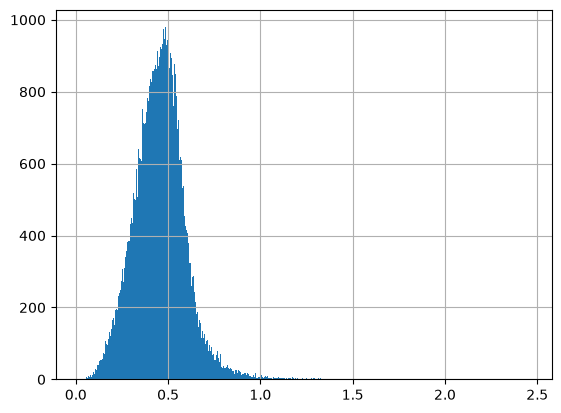

In [14]:
(df['I2']).hist(bins=1000)

<Axes: >

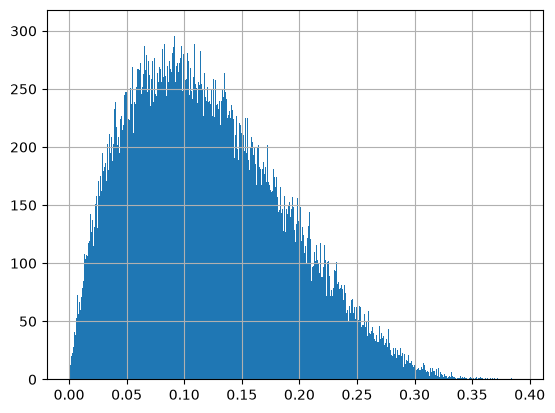

In [15]:
(df['I1']*df['I2']).hist(bins=1000)

In [133]:
df['I12'] = df['I1'] * df['I2']

In [135]:
df[['I12','OR2', 'OR3', 'OR4']].corr()

,I12,OR2,OR3,OR4
I12,1.000000,0.000511,-0.003467,0.005028
OR2,0.000511,1.000000,-0.304619,-0.061605
OR3,-0.003467,-0.304619,1.000000,-0.019171
OR4,0.005028,-0.061605,-0.019171,1.000000


In [32]:
dfmin = df[['I1', 'I2', 'I3', 'I4']]
corr = dfmin.corr(method="spearman", numeric_only=True)
corr

,I1,I2,I3,I4
I1,1.000000,0.150427,-0.498692,-0.746038
I2,0.150427,1.000000,0.070657,-0.574897
I3,-0.498692,0.070657,1.000000,0.043831
I4,-0.746038,-0.574897,0.043831,1.000000


In [39]:
df["I3-I1"] = df["I3"] - df["I1"]

## 3rd minima estimates

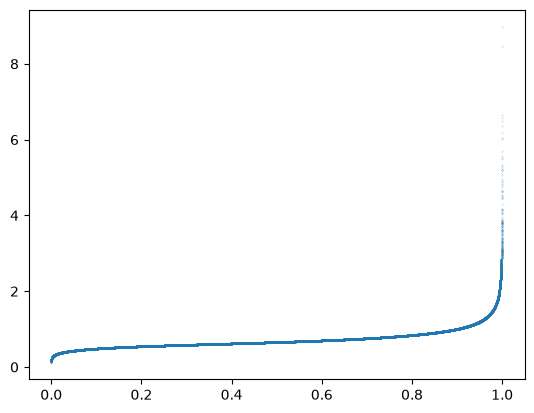

In [252]:
d = (df["I3"]).to_numpy() 

n = len(d)
x = np.sort(d)
plt.scatter(np.arange(n)/n, x, s = 0.01)

# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 1000)

# y = number of samples bigger than x
counts = np.array([(d > x).sum() for x in x_vals]) / n

# optional: fit only the tail, e.g. fit_quantile=0.7
threshold = np.quantile(d, 1 - 0.99)

mask = (x_vals > 0) & (counts < 0) & (x_vals <= threshold)



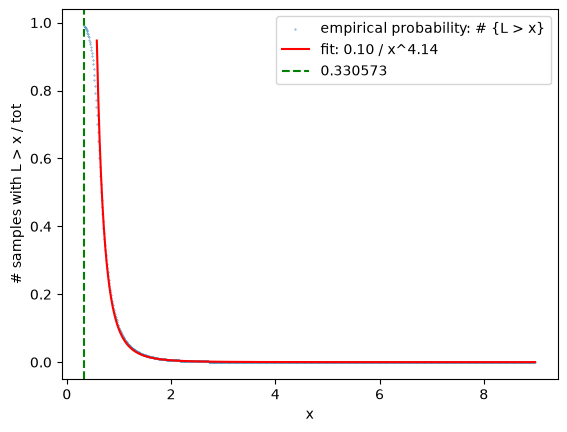

In [253]:
# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 1000)

# y = number of samples bigger than x
counts = np.array([(d > x).sum() for x in x_vals]) / n

# optional: fit only the tail, e.g. fit_quantile=0.7
threshold = np.quantile(d, 1 - 0.99)

mask = (x_vals > 0) & (counts > 0) & (x_vals >= threshold)


log_x = np.log(x_vals[mask])
log_y = np.log(counts[mask])

slope, intercept = np.polyfit(log_x, log_y, 1)

a_hat = -slope
C_hat = np.exp(intercept)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = C_hat * x_vals[mask_pos] ** (-a_hat)

mask_plot = mask_pos & (fit_y < 1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=0.1)

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {C_hat:.2f} / x^{a_hat:.2f}",
         color="red")

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}')

plt.legend()
plt.show()

## 1st and 2nd minima product estimate

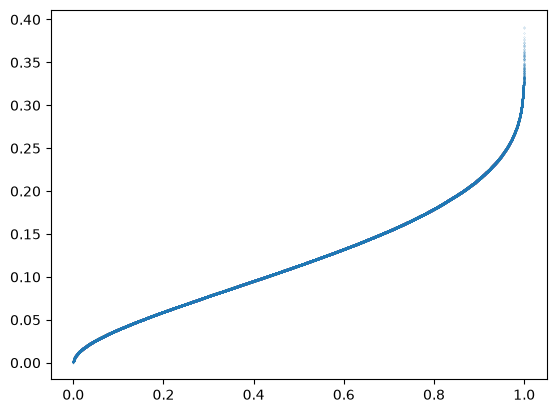

In [267]:
d = (df["I1"]*df["I2"]).to_numpy() 
n = len(d)
x = np.sort(d)
plt.scatter(np.arange(n)/n, x, s = 0.01)

In [293]:
# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 1000)

# y = number of samples bigger than x
counts = np.array([(d < x).sum() for x in x_vals]) / n

# optional: only consider vectors shorter than c * p 
# seems, that c = 0.01 start to give results
threshold = 0.05

# the reason for this sieve is that we expect that for shorter vectors the heuristic will better hold
# and we only care about the short case, corresponding to the long tail for lambda_3
mask = (x_vals > 0) & (counts > 0) & (x_vals <= threshold)

# TODO: understand the number theory behind this

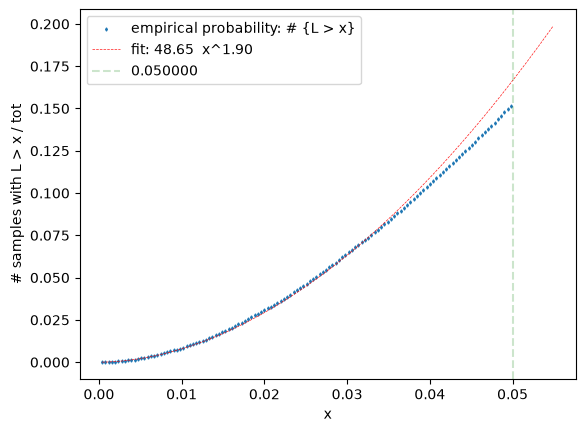

Considering 140 points


In [294]:

log_x = np.log(x_vals[mask])
log_y = np.log(counts[mask])

slope, intercept = np.polyfit(log_x, log_y, 1)

a_hat = slope
C_hat = np.exp(intercept)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = C_hat * x_vals[mask_pos] ** (a_hat)

mask_plot = mask_pos & (fit_y < 1) & (x_vals <= threshold*1.1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=2, marker = 'd')

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {C_hat:.2f}  x^{a_hat:.2f}",
         color="red", alpha=0.9, linestyle="--", linewidth=0.5)

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}', alpha=0.2)

plt.legend()
plt.show()

print(f'Considering {sum([ 1 for m in mask_plot if m])} points')

0.02

In [ ]:
# empirical tail probability P(L >= x)
tail_prob = 1 - np.arange(n) / n
plt.scatter(np.log(x), np.log(tail_prob), s=10)
plt.xlabel("log x")
plt.ylabel("log P(L >= x)")
plt.title("Log-log empirical tail")
plt.show()

In [83]:
q = 0.99
threshold = np.quantile(d, q)

mask = x >= threshold

log_x = np.log(x[mask])
log_tail = np.log(tail_prob[mask])

slope, intercept = np.polyfit(log_x, log_tail, 1)

a_hat = -slope

print(f"Estimated a ≈ {a_hat:.3f}")
print(f"log C ≈ {intercept:.3f}")

Estimated a ≈ 4.019
log C ≈ -2.252


In [49]:
target = "I4"
features = ['I1']

X = df[features].to_numpy()
X = np.column_stack([X, np.ones(len(df))])

z = df[target].to_numpy()

coeffs = np.linalg.lstsq(X, z, rcond=None)[0]

weights = coeffs[:-1]


print("coefficients:", dict(zip(features, weights)))
print("intercept:", intercept)

z_pred = df[features].to_numpy() @ weights + intercept

r2 = 1 - np.sum((z - z_pred) ** 2) / np.sum((z - z.mean()) ** 2)

print(f"R² = {r2:.3f}")

coefficients: {'I1': np.float64(-6.026414281406204)}
intercept: 3.0933218704260916
R² = 0.129


In [16]:
df.describe()

,I1,I2,I3,I4,OL2,OL3,OL4,OR2,OR3,OR4,...,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
count,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,...,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000,121120.000000
mean,0.262799,0.456454,0.719456,1.509584,0.194376,0.495203,1.066281,0.196199,0.465676,1.759294,...,0.532406,0.532571,0.530515,0.532406,0.534049,0.535502,0.533892,0.532571,0.535502,0.536584
std,0.117512,0.143718,0.286950,1.975172,0.107250,0.175087,0.549185,0.102871,0.282452,24.624718,...,0.498951,0.498940,0.499070,0.498951,0.498841,0.498740,0.498852,0.498940,0.498740,0.498662
min,0.001862,0.013268,0.116365,0.528733,0.030987,0.190252,0.489042,0.000133,0.011678,0.404751,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.172409,0.365213,0.566795,0.844443,0.118475,0.368068,0.607113,0.113567,0.335197,0.637247,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.261098,0.454812,0.657058,1.082301,0.205011,0.406916,0.945340,0.191641,0.421954,0.879205,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,0.350080,0.536512,0.794312,1.562725,0.277698,0.560103,1.273252,0.274810,0.519261,1.438507,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,0.624160,2.456409,8.983275,206.441847,0.413080,1.155270,3.761326,0.492326,15.047734,8073.682680,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
df.iloc[:, :4].quantile([1-1/4**i for i in range(1,10)])

,I1,I2,I3,I4
0.750000,0.350080,0.536512,0.794312,1.562725
0.937500,0.448379,0.658708,1.129371,3.108472
0.984375,0.502580,0.816965,1.600381,6.113044
0.996094,0.536830,1.028281,2.280984,12.234309
0.999023,0.561810,1.323357,3.188625,22.832889
0.999756,0.587124,1.604881,4.626790,43.982202
0.999939,0.602517,1.876560,6.028838,72.422993
0.999985,0.610986,2.047418,6.917371,118.228189
0.999996,0.618400,2.312445,8.745214,170.980791


<Axes: >

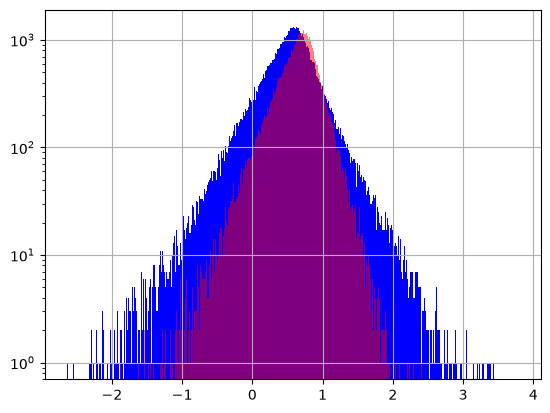

In [59]:
np.log(6*df['I4']*df['I1']).hist(bins=800, log=True, color='blue')
np.log(1.3/df['I3']).hist(bins=800, log=True, alpha=0.5, color='red')

np.float64(0.37213374468177024)

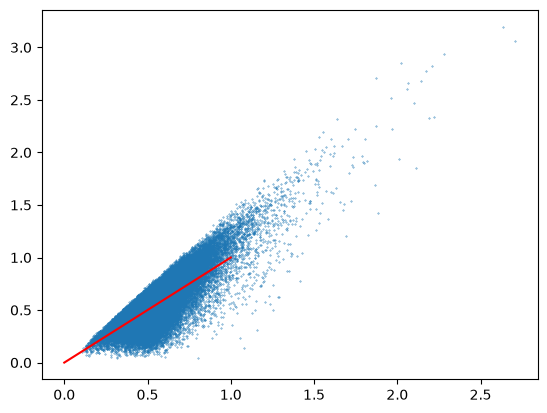

In [64]:
fun1 = np.sqrt(df['I1'] * df['I4'])
m = (fun1 * df['I3']).mean()
plt.scatter(fun1, m/(df['I3']), s=0.1)
plt.plot((0,1), (0,1), 'red')
m

np.float64(0.08967262331255478)

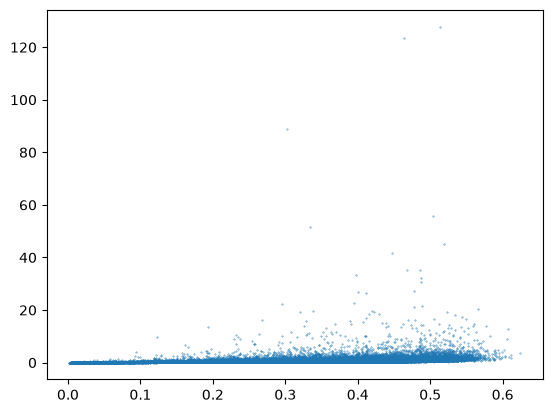

In [43]:
m = (df['I1'] * df['I3-I1']).mean()
plt.scatter(df['I1'], m/df['I3-I1'], s=0.1)
#plt.plot((0,1), (0,1), 'red')
m

np.float64(0.3134985534315788)

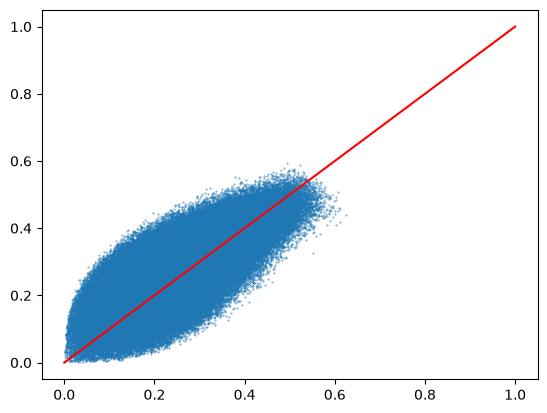

In [24]:
m = (df['I1'] * df['I4']).mean()
plt.scatter(df['I1'], m/df['I4'], s=0.1)
plt.plot((0,1), (0,1), 'red')
m

In [160]:
p = 62

# Use the newest merged file for this p.
files = sorted(Path('.').glob(f'data/{p}-eichler-*.csv'))
if not files:
    raise FileNotFoundError(f'No merged CSV found for p={p}')
data_file = files[-1]
data_file

PosixPath('data/62-eichler-20260708-163832.csv')

In [161]:
columns = (
    ['I1', 'I2', 'I3', 'I4']
    + ['O2', 'O3', 'O4'])

dfe = pd.read_csv(data_file, comment='#', header=None, names=columns)
dfe

,I1,I2,I3,I4,O2,O3,O4
0,0.287386,0.323402,0.662904,1.188033,1.183417,3.273735,14.992062
1,0.217884,0.230236,1.245041,1.297529,0.001258,0.002800,0.003858
2,0.314933,0.419940,0.698422,0.766885,1.357584,1.996005,21.822170
3,0.345258,0.461752,0.630007,0.863656,0.309842,4.193307,44.981555
4,0.288934,0.410742,0.561595,1.151140,1.527311,6.006598,6.392383
...,...,...,...,...,...,...,...
19995,0.287286,0.389125,0.779023,0.913801,3.648230,4.078490,4.832182
19996,0.210777,0.337552,0.590412,1.902497,0.000220,0.001539,0.039231
19997,0.094773,0.320894,1.156256,2.039578,1.171501,1.246001,44.832528
19998,0.373252,0.383814,0.605589,0.917576,0.323287,3.289561,54.967134


In [165]:
dfe.corr()

,I1,I2,I3,I4,O2,O3,O4,I12
I1,1.000000,0.058984,-0.498178,-0.366100,0.010104,0.007747,0.008182,0.918376
I2,0.058984,1.000000,-0.010251,-0.322274,-0.010647,-0.000452,0.006856,0.379022
I3,-0.498178,-0.010251,1.000000,0.036895,-0.003603,-0.008022,-0.003237,-0.430025
I4,-0.366100,-0.322274,0.036895,1.000000,-0.001121,-0.005707,0.000748,-0.404146
O2,0.010104,-0.010647,-0.003603,-0.001121,1.000000,-0.090303,-0.105867,0.003753
O3,0.007747,-0.000452,-0.008022,-0.005707,-0.090303,1.000000,-0.017087,0.007804
O4,0.008182,0.006856,-0.003237,0.000748,-0.105867,-0.017087,1.000000,0.013846
I12,0.918376,0.379022,-0.430025,-0.404146,0.003753,0.007804,0.013846,1.000000


In [164]:
dfe['I12'] = dfe['I1'] * dfe['I2']

np.float64(0.21922453304634956)

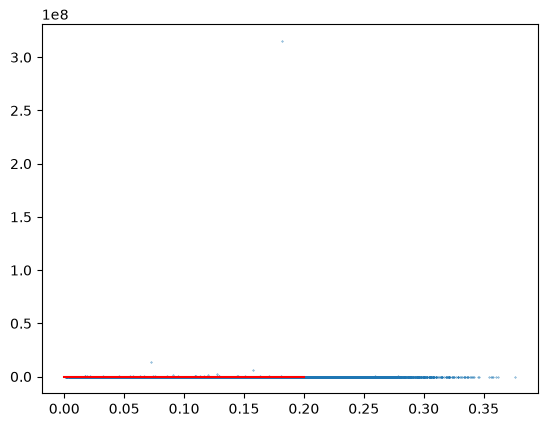

In [169]:
m = (dfe['I12'] * dfe['O2']).mean()
plt.scatter(dfe['I12'], m/dfe['O2'], s=0.1)
plt.plot((0,0.2), (0,0.2), 'red')
m

np.float64(0.08426160801119466)

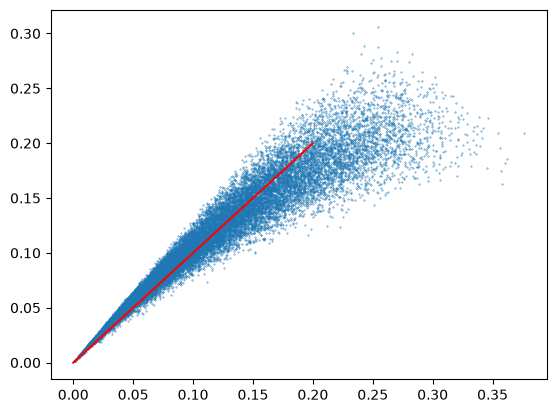

In [179]:
m = (dfe['I12'] * dfe['I3']*dfe['I4']).mean()
plt.scatter(dfe['I12'], m/ (dfe['I3']*dfe['I4']), s=0.1)
plt.plot((0,0.2), (0,0.2), 'red')
m